# 4. LightGBM — Predicting Smartphone Addiction

Segundo modelo de árboles, para batir o empatar el **CV AUC 0,96478** de `3_xgboost.ipynb` y —sobre
todo— para aportar **diversidad al ensamble**.

LightGBM hace crecer los árboles *leaf-wise* (expande siempre la hoja de mayor ganancia) en vez del
*level-wise* de XGBoost. Eso lo hace más expresivo por árbol y le da un sesgo inductivo distinto, que
es exactamente lo que se busca para promediar dos modelos. Medición previa sobre estos datos, mismo
fold y mismo presupuesto de 200 árboles: **LightGBM 0,96002 contra XGBoost 0,95636**.

Se mantiene todo lo demás igual al notebook anterior para que la comparación sea limpia: NaN sin
imputar, categóricas nativas, `StratifiedKFold(5)` con la misma semilla, early stopping por fold y
predicción de test promediada entre los 5 modelos.

> **Nota sobre el alcance.** Acá se corre **una sola configuración de features** (`crudas + derivadas`),
> no las dos. El XGBoost ya respondió esa pregunta: las derivadas valían +0,0004: dentro del ruido
> entre folds. A ~107 s por cada 1000 árboles, repetir la comparación costaba ~20 min para confirmar
> algo ya sabido.

> **Tiempo de ejecución: ~20-25 minutos**, en CPU.

**Métrica:** ROC AUC · **Dataset:** Playground Series S6E8

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from scipy.stats import rankdata
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (15, 6)
plt.rcParams["figure.dpi"] = 100

SEED    = 42
N_FOLDS = 5

print(f"lightgbm {lgb.__version__}")

lightgbm 4.5.0


## 1. Carga y Preprocesamiento

In [2]:
train_raw = pd.read_csv("../data/train.csv")
test_raw  = pd.read_csv("../data/test.csv")

TARGET = "addicted_label"

crudas_num = ["age", "daily_screen_time_hours", "weekend_screen_time", "social_media_hours",
              "gaming_hours", "work_study_hours", "sleep_hours", "notifications_per_day",
              "app_opens_per_day"]
crudas_cat = ["gender", "stress_level", "academic_work_impact"]


def agregar_derivadas(df):
    """Identica a la de 2_logit.ipynb y 3_xgboost.ipynb."""
    d = df.copy()
    componentes = ["social_media_hours", "gaming_hours", "work_study_hours"]
    d["otro_uso"]      = d["daily_screen_time_hours"] - d[componentes].sum(axis=1)
    d["ocio_horas"]    = d["social_media_hours"] + d["gaming_hours"]
    d["screen_sleep"]  = d["daily_screen_time_hours"] / d["sleep_hours"]
    d["social_ratio"]  = d["social_media_hours"] / d["daily_screen_time_hours"]
    d["gaming_ratio"]  = d["gaming_hours"] / d["daily_screen_time_hours"]
    d["weekend_ratio"] = d["weekend_screen_time"] / d["daily_screen_time_hours"]
    d["min_per_open"]  = d["daily_screen_time_hours"] * 60 / d["app_opens_per_day"]
    return d.replace([np.inf, -np.inf], np.nan)


derivadas = ["otro_uso", "ocio_horas", "screen_sleep", "social_ratio",
             "gaming_ratio", "weekend_ratio", "min_per_open"]

train = agregar_derivadas(train_raw)
test  = agregar_derivadas(test_raw)
y     = train[TARGET].values

# Dtype categorico con vocabulario compartido entre train y test
for col in crudas_cat:
    niveles = sorted(set(train[col].dropna()) | set(test[col].dropna()))
    dtype   = pd.CategoricalDtype(categories=niveles, ordered=False)
    train[col] = train[col].astype(dtype)
    test[col]  = test[col].astype(dtype)

features = crudas_num + derivadas + crudas_cat

print(f"Train: {train.shape[0]:,} filas x {train.shape[1]} columnas")
print(f"Test:  {test.shape[0]:,} filas x {test.shape[1]} columnas")
print(f"Features ({len(features)}): {len(crudas_num)} crudas + {len(derivadas)} derivadas "
      f"+ {len(crudas_cat)} categoricas")
print(f"Tasa base P(y=1): {y.mean():.4f}")

Train: 691,369 filas x 21 columnas
Test:  296,302 filas x 20 columnas
Features (19): 9 crudas + 7 derivadas + 3 categoricas
Tasa base P(y=1): 0.7094


## 2. Configuración del Modelo

Dos detalles propios de LightGBM que conviene no pasar por alto:

- **`num_leaves` es la palanca de complejidad**, no `max_depth`. Al crecer *leaf-wise*, un árbol de 63
  hojas es bastante más expresivo que uno level-wise de profundidad 6 (que tiene como máximo 64 hojas
  pero balanceadas). Por eso alcanza un AUC similar con menos árboles.
- **`subsample` no hace nada sin `subsample_freq`**. Es un error clásico: si no se indica cada cuántas
  iteraciones remuestrear, el submuestreo queda desactivado en silencio.

El techo de 5000 árboles es holgado a propósito: en `3_xgboost.ipynb` el tope de 3000 quedó corto y
varios folds cortaron cerca del límite.

In [3]:
PARAMS = dict(
    objective="binary",
    metric="auc",
    n_estimators=5000,          # techo holgado; decide el early stopping
    learning_rate=0.05,
    num_leaves=63,
    min_child_samples=50,
    subsample=0.8,
    subsample_freq=1,           # sin esto, subsample se ignora
    colsample_bytree=0.8,
    reg_lambda=1.0,
    importance_type="gain",     # comparable con la de XGBoost
    random_state=SEED,
    n_jobs=-1,
    verbose=-1,
)


def cv_lightgbm(X, y, X_test, params, skf, etiqueta=""):
    """5-fold CV con early stopping. Devuelve OOF real y test promediado entre folds."""
    oof      = np.zeros(len(X), dtype=np.float32)
    test_sum = np.zeros(len(X_test), dtype=np.float32)
    aucs, iters, modelos = [], [], []

    print(f"{'='*62}")
    print(f"CROSS-VALIDATION — {etiqueta}")
    print(f"{'='*62}")

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
        modelo = lgb.LGBMClassifier(**params)
        modelo.fit(
            X.iloc[tr_idx], y[tr_idx],
            eval_set=[(X.iloc[val_idx], y[val_idx])],
            eval_metric="auc",
            callbacks=[lgb.early_stopping(200, verbose=False), lgb.log_evaluation(0)],
        )

        p_val         = modelo.predict_proba(X.iloc[val_idx])[:, 1]
        oof[val_idx]  = p_val
        test_sum     += modelo.predict_proba(X_test)[:, 1]

        auc = roc_auc_score(y[val_idx], p_val)
        aucs.append(auc)
        iters.append(modelo.best_iteration_)
        modelos.append(modelo)
        print(f"  Fold {fold}: AUC = {auc:.5f}  |  best_iteration = {modelo.best_iteration_}")

    print(f"{'='*62}")
    print(f"  Media: {np.mean(aucs):.5f} +/- {np.std(aucs):.5f}")
    print(f"  AUC out-of-fold: {roc_auc_score(y, oof):.5f}")
    print(f"  Arboles usados (media): {np.mean(iters):.0f}")
    print(f"{'='*62}")

    return dict(oof=oof, test=test_sum / skf.get_n_splits(),
                aucs=aucs, iters=iters, modelos=modelos)

## 3. Validación Cross-Validation

In [4]:
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

res      = cv_lightgbm(train[features], y, test[features], PARAMS, skf,
                       etiqueta="LightGBM — crudas + derivadas")
cv_mean  = np.mean(res["aucs"])
oof_lgb  = res["oof"]
test_lgb = res["test"]

CROSS-VALIDATION — LightGBM — crudas + derivadas
  Fold 1: AUC = 0.96339  |  best_iteration = 1524
  Fold 2: AUC = 0.96413  |  best_iteration = 1901
  Fold 3: AUC = 0.96444  |  best_iteration = 1404
  Fold 4: AUC = 0.96515  |  best_iteration = 1433
  Fold 5: AUC = 0.96399  |  best_iteration = 1632
  Media: 0.96422 +/- 0.00058
  AUC out-of-fold: 0.96422
  Arboles usados (media): 1579


## 4. Diagnóstico — Curva ROC y Separación de Probabilidades

AUC out-of-fold: 0.96422


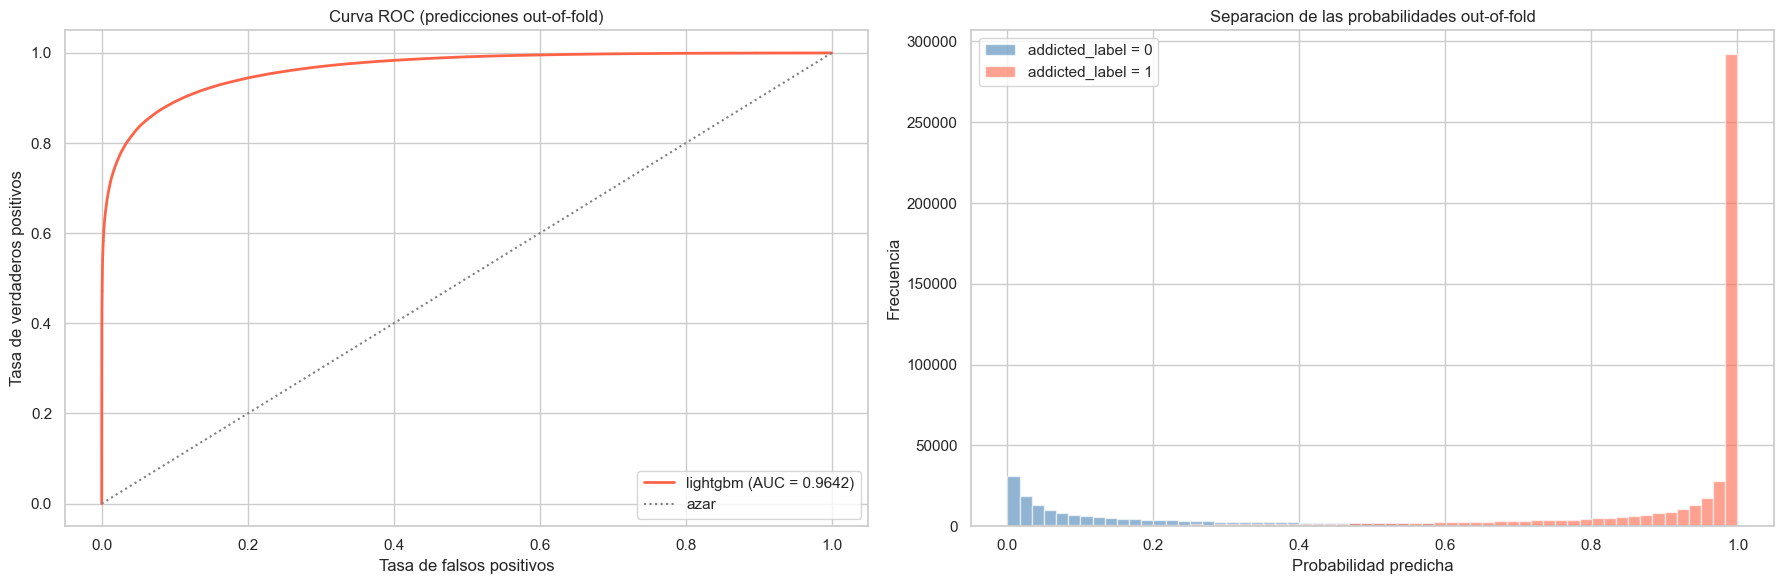

In [5]:
auc_oof = roc_auc_score(y, oof_lgb)
print(f"AUC out-of-fold: {auc_oof:.5f}")

fpr, tpr, _ = roc_curve(y, oof_lgb)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
axes[0].plot(fpr, tpr, color="tomato", lw=2, label=f"lightgbm (AUC = {auc_oof:.4f})")
axes[0].plot([0, 1], [0, 1], color="gray", ls=":", lw=1.5, label="azar")
axes[0].set_xlabel("Tasa de falsos positivos")
axes[0].set_ylabel("Tasa de verdaderos positivos")
axes[0].set_title("Curva ROC (predicciones out-of-fold)")
axes[0].legend(loc="lower right")
for cls, color in [(0, "steelblue"), (1, "tomato")]:
    axes[1].hist(oof_lgb[y == cls], bins=60, alpha=0.6, color=color,
                 label=f"addicted_label = {cls}")
axes[1].set_xlabel("Probabilidad predicha")
axes[1].set_ylabel("Frecuencia")
axes[1].set_title("Separacion de las probabilidades out-of-fold")
axes[1].legend()
plt.tight_layout()
plt.show()

## 5. Feature Importance

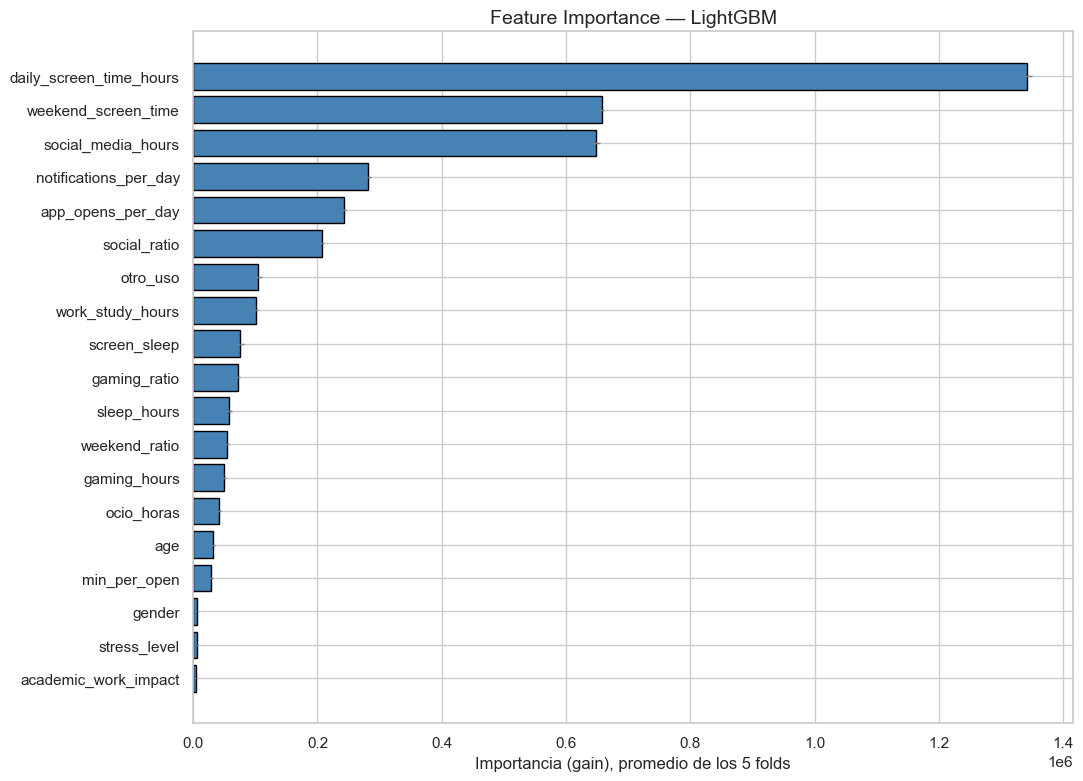

Importancia normalizada (suma = 1):
daily_screen_time_hours    0.3347
weekend_screen_time        0.1640
social_media_hours         0.1615
notifications_per_day      0.0702
app_opens_per_day          0.0604
social_ratio               0.0516
otro_uso                   0.0262
work_study_hours           0.0250
screen_sleep               0.0188
gaming_ratio               0.0180
sleep_hours                0.0144
weekend_ratio              0.0134
gaming_hours               0.0122
ocio_horas                 0.0103
age                        0.0079
min_per_open               0.0072
gender                     0.0016
stress_level               0.0015
academic_work_impact       0.0010


In [6]:
imps      = pd.DataFrame([m.feature_importances_ for m in res["modelos"]], columns=features)
imp_media = imps.mean().sort_values()
imp_std   = imps.std().reindex(imp_media.index)

fig, ax = plt.subplots(figsize=(11, max(6, len(features) * 0.42)))
ax.barh(imp_media.index, imp_media.values, xerr=imp_std.values,
        color="steelblue", edgecolor="black", error_kw=dict(ecolor="gray", lw=1))
ax.set_xlabel("Importancia (gain), promedio de los 5 folds")
ax.set_title("Feature Importance — LightGBM", fontsize=14)
plt.tight_layout()
plt.show()

# Normalizada, para poder compararla con la de XGBoost (que viene en escala 0-1)
imp_norm = (imp_media / imp_media.sum()).sort_values(ascending=False)
print("Importancia normalizada (suma = 1):")
print(imp_norm.round(4).to_string())

## 6. Comparación con los Modelos Previos

In [7]:
AUC_LOGIT = 0.91687   # CV de 2_logit.ipynb
AUC_XGB   = 0.96478   # CV de 3_xgboost.ipynb (crudas + derivadas)

comparativa = pd.DataFrame({
    "modelo": ["Logit (2_logit.ipynb)", "XGBoost (3_xgboost.ipynb)", "LightGBM (este notebook)"],
    "CV AUC": [AUC_LOGIT, AUC_XGB, cv_mean],
})
comparativa["delta vs XGBoost"] = (comparativa["CV AUC"] - AUC_XGB).round(5)

print(f"{'='*62}")
print("COMPARATIVA DE MODELOS")
print(f"{'='*62}")
print(comparativa.round(5).to_string(index=False))
print(f"{'='*62}")

COMPARATIVA DE MODELOS
                   modelo  CV AUC  delta vs XGBoost
    Logit (2_logit.ipynb) 0.91687          -0.04791
XGBoost (3_xgboost.ipynb) 0.96478           0.00000
 LightGBM (este notebook) 0.96422          -0.00056


## 7. Ensamble con XGBoost

`3_xgboost.ipynb` dejó guardadas sus predicciones out-of-fold, y ambos notebooks usan el **mismo
`StratifiedKFold(5, shuffle=True, random_state=42)`**, así que los OOF están alineados fila por fila y
se pueden combinar sin leakage.

Se promedia por **rango** y no por probabilidad: la métrica es AUC, que sólo mira el ordenamiento, y
el promedio de rangos es inmune a que los dos modelos estén calibrados en escalas distintas.

Correlacion de rangos entre los OOF: 0.9955
(cuanto mas baja, mas diversidad y mas puede aportar el ensamble)

 peso_lgb  AUC_oof
      0.0  0.96478
      0.1  0.96486
      0.2  0.96492
      0.3  0.96494
      0.4  0.96493
      0.5  0.96489
      0.6  0.96482
      0.7  0.96472
      0.8  0.96458
      0.9  0.96442
      1.0  0.96422

  Mejor peso para LightGBM: 0.30
  AUC del ensamble:         0.96494
  Mejor modelo individual:  0.96478
  Ganancia del ensamble:    +0.00016


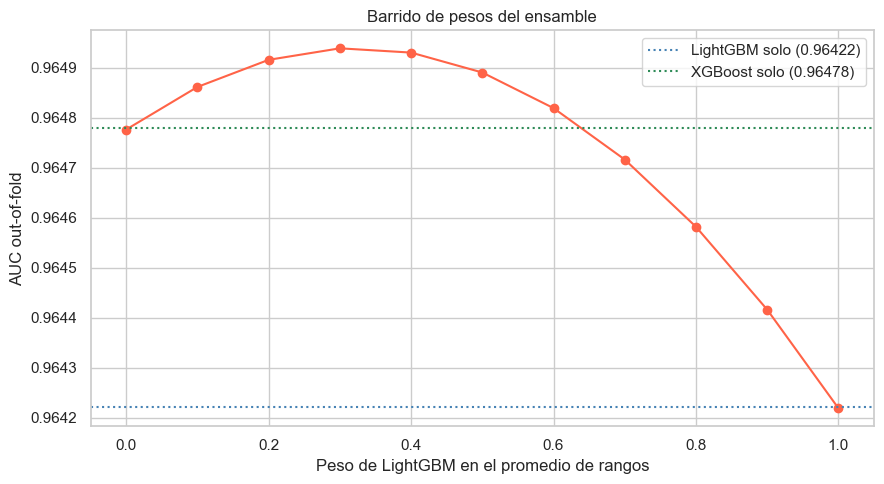

In [8]:
oof_xgb  = np.load("../models/3_xgboost_oof.npy")
test_xgb = np.load("../models/3_xgboost_test.npy")

print(f"Correlacion de rangos entre los OOF: "
      f"{np.corrcoef(rankdata(oof_lgb), rankdata(oof_xgb))[0, 1]:.4f}")
print("(cuanto mas baja, mas diversidad y mas puede aportar el ensamble)\n")

r_lgb = rankdata(oof_lgb) / len(oof_lgb)
r_xgb = rankdata(oof_xgb) / len(oof_xgb)

filas = []
for w in np.round(np.arange(0.0, 1.01, 0.1), 2):
    filas.append({"peso_lgb": w, "AUC_oof": roc_auc_score(y, w * r_lgb + (1 - w) * r_xgb)})
barrido = pd.DataFrame(filas)

MEJOR_W  = barrido.loc[barrido["AUC_oof"].idxmax(), "peso_lgb"]
AUC_BLEND = barrido["AUC_oof"].max()

print(barrido.round(5).to_string(index=False))
print(f"\n  Mejor peso para LightGBM: {MEJOR_W:.2f}")
print(f"  AUC del ensamble:         {AUC_BLEND:.5f}")
print(f"  Mejor modelo individual:  {max(cv_mean, AUC_XGB):.5f}")
print(f"  Ganancia del ensamble:    {AUC_BLEND - max(cv_mean, AUC_XGB):+.5f}")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(barrido["peso_lgb"], barrido["AUC_oof"], marker="o", color="tomato")
ax.axhline(cv_mean, color="steelblue", ls=":", lw=1.5, label=f"LightGBM solo ({cv_mean:.5f})")
ax.axhline(AUC_XGB, color="seagreen", ls=":", lw=1.5, label=f"XGBoost solo ({AUC_XGB:.5f})")
ax.set_xlabel("Peso de LightGBM en el promedio de rangos")
ax.set_ylabel("AUC out-of-fold")
ax.set_title("Barrido de pesos del ensamble")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Predicción sobre Test y Submission

In [9]:
# a) LightGBM solo
submission = pd.DataFrame({"id": test["id"], TARGET: test_lgb})
submission.to_csv("../submissions/4_lightgbm_submission.csv", index=False)

np.save("../models/4_lightgbm_oof.npy",  oof_lgb)
np.save("../models/4_lightgbm_test.npy", test_lgb)

# b) Ensamble con XGBoost, con el peso elegido por el barrido OOF
rt_lgb = rankdata(test_lgb) / len(test_lgb)
rt_xgb = rankdata(test_xgb) / len(test_xgb)
blend  = MEJOR_W * rt_lgb + (1 - MEJOR_W) * rt_xgb

submission_blend = pd.DataFrame({"id": test["id"], TARGET: blend})
submission_blend.to_csv("../submissions/4_lgbm_xgb_blend_submission.csv", index=False)

print(f"LightGBM solo -> ../submissions/4_lightgbm_submission.csv")
print(f"  proba media: {test_lgb.mean():.4f}  (tasa base train: {y.mean():.4f})")
print(f"\nEnsamble     -> ../submissions/4_lgbm_xgb_blend_submission.csv  (peso lgb={MEJOR_W:.2f})")
print(f"  OJO: el blend son rangos normalizados en [0, 1], no probabilidades calibradas.")
print(f"  Para AUC da igual, pero no se puede leer como P(y=1).")

LightGBM solo -> ../submissions/4_lightgbm_submission.csv
  proba media: 0.7099  (tasa base train: 0.7094)

Ensamble     -> ../submissions/4_lgbm_xgb_blend_submission.csv  (peso lgb=0.30)
  OJO: el blend son rangos normalizados en [0, 1], no probabilidades calibradas.
  Para AUC da igual, pero no se puede leer como P(y=1).


In [10]:
# Chequeo de sanidad de ambas submissions contra sample_submission
sample = pd.read_csv("../data/sample_submission.csv")
for nombre, sub in [("LightGBM", submission), ("Ensamble", submission_blend)]:
    assert list(sub.columns) == list(sample.columns), f"{nombre}: columnas no coinciden"
    assert len(sub) == len(sample), f"{nombre}: cantidad de filas no coincide"
    assert (sub["id"].values == sample["id"].values).all(), f"{nombre}: ids no alineados"
    assert sub[TARGET].between(0, 1).all(), f"{nombre}: valores fuera de [0, 1]"
    assert sub[TARGET].notna().all(), f"{nombre}: hay nulos"
    print(f"  {nombre}: OK")
print("\nChequeos OK — ambas submissions listas.")

  LightGBM: OK
  Ensamble: OK

Chequeos OK — ambas submissions listas.


## 9. Envío a Kaggle vía API

Enviar **la que haya ganado en OOF**: si la sección 7 muestra ganancia del ensamble, mandar el blend;
si no, el LightGBM solo. La variable `FILE` de abajo ya elige sola en función del barrido.

In [11]:
usar_blend  = AUC_BLEND > max(cv_mean, AUC_XGB)

COMPETITION = "playground-series-s6e8"
FILE        = ("../submissions/4_lgbm_xgb_blend_submission.csv" if usar_blend
               else "../submissions/4_lightgbm_submission.csv")
MSG         = (f"LGBM+XGB rank blend w={MEJOR_W:.2f} - OOF AUC={AUC_BLEND:.5f}" if usar_blend
               else f"LightGBM - cat nativas + NaN nativos - CV AUC={cv_mean:.5f}")

print(f"Se enviara: {FILE}")
print(f"Mensaje:    {MSG}")

Se enviara: ../submissions/4_lgbm_xgb_blend_submission.csv
Mensaje:    LGBM+XGB rank blend w=0.30 - OOF AUC=0.96494


In [12]:
!kaggle competitions submit -c {COMPETITION} -f "{FILE}" -m "{MSG}"

Successfully submitted to Predicting Smartphone Addiction



  0%|          | 0.00/7.71M [00:00<?, ?B/s]
  0%|          | 16.0k/7.71M [00:00<01:08, 117kB/s]
  6%|▌         | 464k/7.71M [00:00<00:12, 620kB/s] 
  6%|▋         | 512k/7.71M [00:01<00:17, 423kB/s]
  7%|▋         | 576k/7.71M [00:01<00:17, 440kB/s]
  8%|▊         | 624k/7.71M [00:01<00:17, 417kB/s]
 45%|████▌     | 3.47M/7.71M [00:01<00:00, 5.59MB/s]
100%|██████████| 7.71M/7.71M [00:02<00:00, 3.11MB/s]


In [13]:
# Score publico del envio (esperar unos segundos a que Kaggle lo puntue)
!kaggle competitions submissions -c playground-series-s6e8

     ref  fileName                         date                        description                                           status                     publicScore  privateScore  
--------  -------------------------------  --------------------------  ----------------------------------------------------  -------------------------  -----------  ------------  
55536391  4_lgbm_xgb_blend_submission.csv  2026-08-15 21:31:28.430000  LGBM+XGB rank blend w=0.30 - OOF AUC=0.96494          SubmissionStatus.PENDING                              
55419015  3_xgboost_submission.csv         2026-08-11 00:30:06.843000  XGBoost - cat nativas + NaN nativos - CV AUC=0.96478  SubmissionStatus.COMPLETE  0.96634                    
55393493  2_logit_submission.csv           2026-08-10 01:23:28.337000  Logit - crudas + derivadas - CV AUC=0.91687           SubmissionStatus.COMPLETE  0.91909                    


## 10. Conclusiones

- **CV AUC = 0,96422** (±0,00058), con el OOF dando exactamente lo mismo. Queda **0,00056 por debajo
  del XGBoost** (0,96478). Esa diferencia es **estadísticamente real**: el análisis pareado de
  `7_ruido_y_significancia.ipynb` le da z = 14,6 sobre las mismas filas. (En una primera lectura la
  comparé contra el desvío entre folds y la descarté como empate; era el estadístico equivocado —
  ver ese notebook.) Además, la ventaja que LightGBM mostraba a 200 árboles (0,96002 vs 0,95636) **no
  sobrevivió a la convergencia**: era ventaja de arranque, no de techo.
- **Converge en 1579 árboles promedio contra los 2215 de XGBoost** (−29 %), y muy lejos del techo de
  5000. El crecimiento *leaf-wise* cumple lo que promete en eficiencia por árbol; lo que no da es más
  techo de performance.
- **Los dos modelos ven casi lo mismo**: la correlación de rangos entre los OOF es **0,9955**. Ese
  número explica todo lo que sigue.
- **El ensamble aporta +0,00016** (0,96478 → 0,96494, con peso 0,30 para LightGBM), y la curva del
  barrido es prácticamente plana entre 0,1 y 0,5 — lo esperable al promediar dos modelos redundantes.
  Cuidado con ese +0,00016: el peso se eligió **maximizando ese mismo OOF**, así que la ganancia está
  **sesgada por selección** y no se puede leer como una mejora esperable fuera de muestra.
- **Confirmación cruzada del hallazgo del notebook 3**: `notifications_per_day` (0,0702, 4º puesto) y
  `app_opens_per_day` (0,0604, 5º) escalan **todavía más alto** acá que en XGBoost (0,0414 y 0,0433).
  Dos algoritmos independientes coinciden en encontrarles señal a las dos variables que la correlación
  lineal daba por ruido (−0,012 y 0,064). El hallazgo es real, no un artefacto de un solo modelo.
- **Las categóricas son aún más irrelevantes de lo que parecía**: `gender`, `stress_level` y
  `academic_work_impact` suman 0,004 de importancia **entre las tres**, un orden de magnitud menos que
  en XGBoost. Se podrían descartar sin costo.
- **El leaderboard va sistemáticamente por encima de la CV**: XGBoost sacó **0,96634** público contra
  0,96478 de CV (+0,0016), en la misma dirección que el logit (+0,0022). La validación cruzada es un
  proxy confiable y consistentemente conservador.
- **Confirmación en el leaderboard**: el blend sacó **0,96634**, *exactamente* el mismo score público
  que el XGBoost solo. El +0,00016 de OOF no se tradujo en nada — consistente con que esa ganancia
  viniera del sesgo de selección del peso y no de una mejora genuina. Es el ejemplo limpio de por qué
  una ganancia optimizada sobre el mismo conjunto con el que se la mide no es evidencia de nada.
- **Ambos modelos convergieron solos**: LightGBM cortó en 1579 árboles sobre un techo de 5000, y
  XGBoost en ~2215 sobre 3000 (el fold más largo entrenó ~2856, sin tocar el límite). Ninguno de los
  dos se quedó sin presupuesto: dejaron de mejorar por su cuenta.
- **Dónde no seguir**: con una correlación de rangos de 0,9955 entre GBMs, apilar un tercero (CatBoost)
  tiene techo bajo. Y como ninguno de los dos se frenó por falta de árboles, tampoco hay nada que
  ganar subiendo caps. Lo único que estos modelos **no** tienen es tuning de hiperparámetros: ambos
  corrieron con una sola configuración elegida a mano.
- **Señal de meseta**: tres enfoques distintos (XGBoost, LightGBM y su ensamble) caen dentro de 0,0006
  entre sí, y dos de ellos dan idéntico score público. Eso sugiere que con este conjunto de features
  se está cerca del techo alcanzable, y que lo que queda son mejoras de margen.